In [ ]:
import marimo as mo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# SARIMA — del modelo a un ejemplo con viento

Este notebook tiene **dos partes**:

1. **Teoría** — qué es SARIMA, cómo se relaciona con AR, MA, ARMA e
   ARIMA, y qué significa cada uno de sus parámetros
   `(p, d, q)(P, D, Q, s)`.
2. **Ejemplo** — un ajuste interactivo sobre datos horarios de viento
   de La Ventosa (Oaxaca), con un widget para explorar combinaciones
   y diagnosticar el modelo.

## SARIMA de un vistazo

Un modelo **SARIMA(p, d, q)(P, D, Q)$_s$** se construye a partir de
cinco ideas, en orden creciente de complejidad. Todos los modelos de
abajo son casos particulares del widget — los recuperas poniendo en cero
los órdenes que no quieras usar.

| Modelo | Ajuste del widget | Qué captura |
|---|---|---|
| **AR(p)** | `(p, 0, 0)(0, 0, 0, _)` | El valor actual depende de sus propios `p` rezagos pasados. |
| **MA(q)** | `(0, 0, q)(0, 0, 0, _)` | El valor actual depende de los últimos `q` choques (errores). |
| **ARMA(p, q)** | `(p, 0, q)(0, 0, 0, _)` | Combina ambas ideas — solo para series estacionarias. |
| **ARIMA(p, d, q)** | `(p, d, q)(0, 0, 0, _)` | Diferencia `d` veces para quitar tendencia, luego ARMA. |
| **SARIMA(p, d, q)(P, D, Q)$_s$** | `(p, d, q)(P, D, Q, s)` | ARIMA **más** una copia estacional del AR/I/MA en el rezago `s`. |

### La parte no estacional `(p, d, q)`

- **p** — orden autorregresivo. Usa `y[t-1], y[t-2], …, y[t-p]`.
- **d** — número de diferencias regulares. `d=1` modela `y[t] - y[t-1]`;
  esto elimina una tendencia lenta para que el resto del modelo vea una
  serie estacionaria.
- **q** — orden de media móvil. Usa los errores pasados
  `ε[t-1], …, ε[t-q]`.

### La parte estacional `(P, D, Q, s)`

Las mismas tres perillas, pero actuando en múltiplos del periodo
estacional `s` — el modelo observa `y[t-s], y[t-2s], …` en lugar de
`y[t-1], y[t-2], …`.

- **s** — el periodo del ciclo. Para **datos horarios con patrón
  diario**, fija `s = 24`. Cada hora pronosticada queda anclada a *la
  misma hora de días previos*, que es justo lo que significa el
  "día promedio horario": el modelo aprende su propio perfil diario,
  refinado por la parte no estacional `(p, d, q)` para la dinámica de
  corto plazo.
- **D** — diferenciación estacional. `D=1` modela `y[t] - y[t-s]`. Con
  `s = 24` esto resta "misma hora, día anterior" y quita el ciclo
  diario para que el modelo se concentre en lo que cambia día a día.
- **P** — AR estacional: usa `y[t-s], y[t-2s], …, y[t-Ps]`.
- **Q** — MA estacional: usa errores pasados
  `ε[t-s], ε[t-2s], …, ε[t-Qs]`.

### Cómo el widget recupera cada variante

Usa el formulario de abajo para alternar entre modelos sin reescribir
código:

- **AR(2)** → `p=2, d=0, q=0, P=0, D=0, Q=0` (s es irrelevante)
- **MA(1)** → `p=0, d=0, q=1, P=0, D=0, Q=0`
- **ARMA(2, 1)** → `p=2, d=0, q=1, P=0, D=0, Q=0`
- **ARIMA(2, 1, 1)** → `p=2, d=1, q=1, P=0, D=0, Q=0`
- **SARIMA(2, 0, 1)(1, 1, 1)$_{24}$** → los valores por defecto;
  estacionalidad diaria activa.

### Consejos para esta serie

1. Empieza con `s = 24` y `D = 1` — el viento tiene un ciclo diurno
   fuerte, así que la diferencia estacional suele ser la perilla más útil.
2. Si la ACF de los residuos sigue sobresaliendo en el rezago 24, sube `P` o
   `Q` (rara vez por encima de 2 cada uno) en lugar de `p` o `q`.
3. Mantén `d + D ≤ 2` en total. Sobre-diferenciar infla la varianza y
   produce un peor pronóstico aunque el AIC baje.
4. Compara corridas por **AIC/BIC en entrenamiento** *y* **RMSE en el
   holdout** — un modelo que sobreajusta luce bien en AIC pero peor en
   RMSE.

## La parte estacional `(P, D, Q, s)` — a fondo

### Una analogía: el marinero con dos relojes

Imagina que eres marinero en La Ventosa y quieres anticipar la
velocidad del viento en la próxima hora. Tienes **dos relojes** en la
cabina:

- Un **reloj de pulso**, que te dice qué ha pasado en los últimos
  minutos: *\"hace dos horas que el viento se viene calmando\"*. Este
  reloj es la parte **no estacional** `(p, d, q)`: mira lo inmediato.
- Un **almanaque del día**, que te dice en qué punto del ciclo diario
  estás: *\"son las 14:00, a esta hora todos los días aprieta la brisa
  por el calentamiento solar sobre el istmo\"*. Este reloj es la parte
  **estacional** `(P, D, Q, s)`: mira el **mismo instante de ciclos
  previos**.

Un buen pronóstico combina ambos. SARIMA hace exactamente eso:
multiplica dos modelos ARMA, uno que opera en rezagos consecutivos
`(1, 2, 3, …)` y otro que opera en rezagos estacionales
`(s, 2s, 3s, …)`.

### `s` — el periodo del ciclo

Es el **intervalo del almanaque**: cada cuántas observaciones se repite
el patrón.

| Frecuencia de los datos | Ciclo que esperas | `s` |
|---|---|---|
| Horarios | Diario | `24` |
| Cada 30 min | Diario | `48` |
| Diarios | Semanal | `7` |
| Mensuales | Anual | `12` |

**Pista:** si la ACF de la serie cruda muestra picos regulares en el
rezago `k`, prueba `s = k`.

### `D` — la diferencia estacional (la perilla más poderosa)

`D = 1` transforma la serie en `y[t] - y[t-s]`. En palabras:

> *\"¿Cuánto difiere la observación de ahora respecto al mismo punto del
> ciclo anterior?\"*

Para viento horario con `s = 24`: *\"¿cuánto difiere el viento de hoy a
las 14:00 del viento de ayer a las 14:00?\"*. Esa resta **elimina el
perfil promedio diario** y deja al modelo trabajando solo con las
**desviaciones día-a-día** — que suelen ser mucho más estacionarias y
fáciles de modelar.

**Analogía:** si quieres saber si hoy hace calor *anormal*, no miras la
temperatura cruda — la comparas con el promedio histórico de esta misma
fecha. `D = 1` hace ese \"restar respecto al ciclo previo\"
automáticamente, sin que tengas que calcular el promedio.

### `P` — el AR estacional

Igual que `p`, pero saltando de un ciclo al siguiente. `P = 1` dice:

> *\"El viento de hoy a las 14:00 es proporcional al viento de ayer a
> las 14:00, más algo de ruido.\"*

Con `P = 2` mira ayer **y** antier a la misma hora.

**Analogía:** es la **memoria larga del ritmo**. Como un baterista que
sabe que el platillo suena fuerte en cada cuarto compás — no porque
acaba de sonar fuerte (eso sería `p`), sino porque cada vez que llega
a esa posición del compás, suena fuerte.

### `Q` — el MA estacional

Igual que `q`, pero sobre los **errores** del ciclo anterior. `Q = 1`
dice:

> *\"Si ayer a las 14:00 me equivoqué por +3 km/h, hoy a las 14:00
> arrastro algo de esa corrección.\"*

**Analogía:** un meteorólogo que aprende del error del día anterior a la
misma hora. *\"Ayer subestimé la tarde por 3 km/h — hoy ajusto al
alza.\"*

### Por qué se **multiplican** las dos partes

SARIMA no es \"ARMA + ARMA estacional\" sumados, sino el **producto** de
los polinomios no estacional y estacional. Esto hace aparecer **rezagos
cruzados** sin gastar parámetros extra.

*Ejemplo concreto:* con `p = 1`, `P = 1`, `s = 24`, el modelo termina
usando los rezagos **1**, **24** y **25** simultáneamente — porque el
rezago 25 es \"hace una hora del valor de ayer a esta hora\". Con solo
dos coeficientes capturas dinámica de corto plazo **y** cíclica.

### Cómo se ve en tus residuos

El veredicto rápido sobre `(P, D, Q, s)` no está en el AIC — está en la
**ACF de los residuos** (el panel inferior izquierdo del fit).

- ¿Hay un pico aislado y grande en el rezago **24**? Te falta `D = 1` o
  `Q = 1`.
- ¿Hay un decaimiento lento en los múltiplos de 24 (24, 48, 72)? Sube
  `P` a 1 o 2.
- ¿Los rezagos `≤ 5` siguen con picos? Eso es la parte **no
  estacional** — ajusta `p` o `q`, no `P` ni `Q`.

### Aclaración: `D = 1` **no** calcula un perfil promedio horario

Es una confusión común. SARIMA con `D = 1, s = 24` **no** calcula un
vector de 24 promedios (uno por hora del día sobre todo el
entrenamiento). Lo que hace es una **diferencia rezagada**:

$$
y'[t] \;=\; y[t] - y[t-24]
$$

Compara cada hora con **esa misma hora del día anterior** — uno solo,
no el promedio de todos los días previos.

#### Entonces ¿de dónde sale el \"perfil diario\"?

Emerge **implícitamente**:

- Si el ciclo diario es estable, `y[t]` y `y[t-24]` contienen
  aproximadamente la misma componente cíclica, y al restarlos
  **se cancela**.
- En `y'[t]` solo quedan las **desviaciones día-a-día** respecto al
  ciclo.
- El modelo **nunca guarda** un vector de 24 promedios — ese sería un
  enfoque distinto (descomposición estacional clásica, tipo
  `seasonal_decompose` o STL).

#### Comparación rápida

| Enfoque | Cómo trata la estacionalidad |
|---|---|
| **STL / `seasonal_decompose`** | Calcula un perfil explícito (p. ej. promedio por hora del día sobre todo el train) y lo resta. |
| **SARIMA con `D=1`** | Diferencia rezagada `y[t] - y[t-s]`. El perfil queda **implícito**. |
| **SARIMA con `P, Q` (sin `D`)** | Pondera explícitamente el valor (`P`) o el error (`Q`) del mismo instante de **uno o dos ciclos** anteriores — no de todo el histórico. |

#### Lo importante para tu intuición

Cuando decimos *\"el modelo aprende su propio perfil diario\"* nos
referimos al **comportamiento efectivo**, no a la mecánica interna. Lo
que opera es un rezago, no un promedio. Por eso `D = 1` funciona bien
aunque la serie de entrenamiento sea corta: no necesita muchas vueltas
del ciclo para estimar un promedio robusto, **solo necesita que el
ciclo de ayer y el de hoy se parezcan**.

### ¿Y si `D = 2` o `D = 3`? El triángulo de Pascal

Cada vez que aplicas la diferencia estacional, **compones** el operador
consigo mismo. Si llamamos `L` al operador de rezago un paso
(`L · y[t] = y[t-1]`), entonces la diferencia estacional es:

$$
\nabla_{s} \;=\; (1 - L^{s})
$$

y aplicarla `D` veces es **elevarlo a la `D`**:

$$
\nabla_{s}^{D} \;=\; (1 - L^{s})^{D}
\;=\; \sum_{k=0}^{D} \binom{D}{k}(-1)^{k}\,L^{sk}
$$

Esa es la **fórmula binomial** de toda la vida con `a = 1`, `b = L^{s}` —
de ahí salen los coeficientes del **triángulo de Pascal con signos
alternados**.

#### Cómo queda con `s = 24`

| `D` | Operación expandida | Observaciones que entran |
|---|---|---|
| **1** | `y[t] - y[t-24]` | 2 |
| **2** | `y[t] - 2·y[t-24] + y[t-48]` | 3 |
| **3** | `y[t] - 3·y[t-24] + 3·y[t-48] - y[t-72]` | 4 |
| **4** | `y[t] - 4·y[t-24] + 6·y[t-48] - 4·y[t-72] + y[t-96]` | 5 |

Los coeficientes son los renglones del triángulo:

```
D=1:   1   1
D=2:   1   2   1
D=3:   1   3   3   1
D=4:   1   4   6   4   1
```

Solo que en SARIMA aparecen con **signos alternados** (`+ - + - …`)
porque cada `L^{s}` arrastra un `-1` desde el `(1 - L^{s})` original.

#### Intuición combinatoria

Cada vez que aplicas `(1 - L^{s})`, cada observación o bien **se queda
donde está**, o bien **se rezaga `s` pasos**. Después de `D`
aplicaciones, una observación llega al instante `t - sk` por
$\binom{D}{k}$ caminos distintos — y eso es exactamente lo que cuenta
el coeficiente binomial.

#### Qué interpretar de cada nivel

- `D = 1` quita el **nivel** del ciclo: ¿cuánto cambió esta hora
  respecto a la misma hora de ayer?
- `D = 2` quita además una **tendencia lineal** sobre el ciclo: el
  ciclo diario sube o baja en pendiente constante día a día.
- `D = 3` quita una **aceleración** del ciclo (el ritmo de cambio del
  ciclo cambia). Esto ya es raro en la práctica.

#### Por qué `D` grande amplifica ruido

Mira la última columna de la tabla: cada incremento de `D` mete una
observación más en la suma, **y los coeficientes crecen** (1, 2, 3, 4,
6, …). Estás combinando linealmente más valores, con pesos cada vez
mayores y signos alternados — exactamente la receta para amplificar el
ruido si el ciclo no varía con suficiente complejidad como para
justificarlo.

Por eso la regla práctica es **`d + D ≤ 2`**.

## Síntesis: la ecuación completa de SARIMA

Todo lo anterior se condensa en una sola expresión. Si llamamos `L` al
operador de rezago (`L · y[t] = y[t-1]`) y separamos los cuatro
polinomios — AR, AR estacional, MA, MA estacional — la ecuación de
SARIMA es:

$$
\underbrace{\Phi_P(L^{s})}_{\text{AR estacional}}\,
\underbrace{\phi_p(L)}_{\text{AR}}\,
\underbrace{(1-L^{s})^{D}}_{\text{dif. estacional}}\,
\underbrace{(1-L)^{d}}_{\text{dif. regular}}\,
y[t]
\;=\;
\underbrace{\Theta_Q(L^{s})}_{\text{MA estacional}}\,
\underbrace{\theta_q(L)}_{\text{MA}}\,
\varepsilon[t]
$$

Léelo **de derecha a izquierda** sobre `y[t]`:

1. Primero **diferencias regulares** (`d` veces, paso 1) — quitan
   tendencia.
2. Luego **diferencias estacionales** (`D` veces, paso `s`) — quitan
   el ciclo.
3. Sobre la serie ya estacionaria, aplicas AR no estacional **y** AR
   estacional **simultáneamente**.
4. El lado derecho hace lo mismo con MA, pero sobre los errores
   `ε[t]`.

### Los cuatro polinomios y sus rezagos

| Componente | Polinomio | Rezagos que usa |
|---|---|---|
| **AR no estacional `p`** | $\phi_p(L) = 1 - \phi_1 L - \phi_2 L^2 - \dots - \phi_p L^p$ | `1, 2, …, p` (consecutivos) |
| **AR estacional `P`** | $\Phi_P(L^s) = 1 - \Phi_1 L^s - \Phi_2 L^{2s} - \dots - \Phi_P L^{Ps}$ | `s, 2s, …, Ps` (saltando) |
| **MA no estacional `q`** | $\theta_q(L) = 1 + \theta_1 L + \dots + \theta_q L^q$ | `1, 2, …, q` |
| **MA estacional `Q`** | $\Theta_Q(L^s) = 1 + \Theta_1 L^s + \dots + \Theta_Q L^{Qs}$ | `s, 2s, …, Qs` |

`(p, q)` y `(P, Q)` son **el mismo tipo de operador** — AR y MA — pero
actúan a **escalas temporales distintas**: la no estacional mira paso
a paso, la estacional mira de un ciclo al siguiente.

### Los polinomios se **multiplican** — y eso es la gracia

Cuando juntas $\phi_p(L) \cdot \Phi_P(L^s)$ no solo aparecen los
rezagos individuales, también aparecen **rezagos cruzados gratis**.
Con `p = 1`, `P = 1`, `s = 24`:

$$
(1 - \phi_1 L)(1 - \Phi_1 L^{24})
= 1 - \phi_1 L - \Phi_1 L^{24} + \phi_1 \Phi_1 L^{25}
$$

Aparece el **rezago 25** con coeficiente $\phi_1 \Phi_1$ — sin pagar
parámetros extra. Y tiene sentido físico: *\"hace 25 horas\"* es
*\"hace una hora del valor de ayer a esta hora\"*. Esa es la razón por
la que SARIMA logra capturar dinámicas en múltiples escalas con muy
pocos coeficientes.

### En una frase

> **SARIMA es ARMA aplicado dos veces a la vez** — una en rezagos
> consecutivos `(p, q)` y otra en rezagos del ciclo `(P, Q)` — sobre
> una serie a la que primero se le quitó la tendencia (`d`) y el
> ciclo (`D`, `s`).

---

# Ejemplo: viento horario en La Ventosa

Carguemos los datos, definamos la serie de entrenamiento y ajustemos
un SARIMA interactivamente.

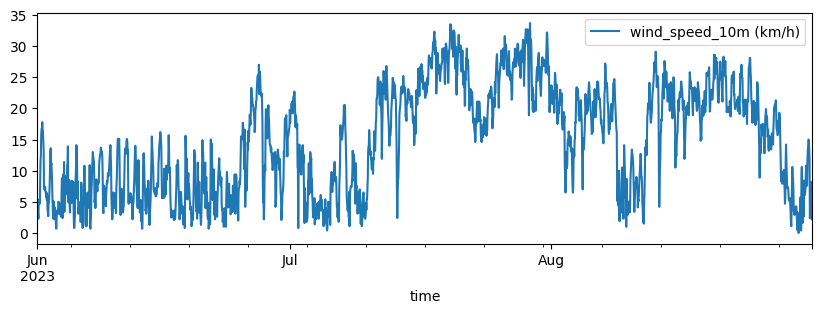

In [ ]:
f = "data/viento_la_ventosa_2023.csv"
viento_all = pd.read_csv(f, skiprows=3, parse_dates=["time"],index_col="time")
viento_all.plot(figsize=(10,3))

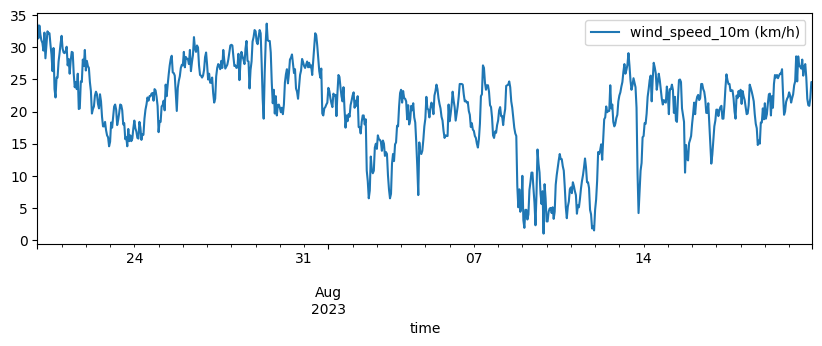

In [ ]:
viento = viento_all.loc["2023-07-20":"2023-08-20"]
y = viento["wind_speed_10m (km/h)"].astype(float).asfreq("h")
viento.plot(figsize=(10, 3))

In [ ]:
# Hold out the last 48 h as a test window for forecast evaluation.
horizon = 48
y_train = y.iloc[:-horizon]
y_test = y.iloc[-horizon:]
mo.md(f"Train: **{len(y_train)}** h ({y_train.index[0]} → {y_train.index[-1]})  \n"
      f"Test:  **{len(y_test)}** h ({y_test.index[0]} → {y_test.index[-1]})")

Train: **720** h (2023-07-20 00:00:00 → 2023-08-18 23:00:00)  
Test:  **48** h (2023-08-19 00:00:00 → 2023-08-20 23:00:00)

In [ ]:
order_form = (
    mo.md(
        """
        **Non-seasonal**  p = {p}, d = {d}, q = {q}

        **Seasonal**      P = {P}, D = {D}, Q = {Q}, s = {s}
        """
    )
    .batch(
        p=mo.ui.slider(0, 5, value=2, label="p"),
        d=mo.ui.slider(0, 2, value=0, label="d"),
        q=mo.ui.slider(0, 5, value=1, label="q"),
        P=mo.ui.slider(0, 2, value=1, label="P"),
        D=mo.ui.slider(0, 1, value=1, label="D"),
        Q=mo.ui.slider(0, 2, value=1, label="Q"),
        s=mo.ui.number(2, 168, value=24, label="s"),
    )
    .form(submit_button_label="Fit SARIMA")
)
order_form

&lt;marimo-form data-initial-value=&#x27;null&#x27; data-label=&#x27;null&#x27; data-element-id=&#x27;&amp;quot;emfo-22&amp;quot;&#x27; data-loading=&#x27;false&#x27; data-bordered=&#x27;true&#x27; data-submit-button-label=&#x27;&amp;quot;Fit SARIMA&amp;quot;&#x27; data-submit-button-disabled=&#x27;false&#x27; data-clear-on-submit=&#x27;false&#x27; data-show-clear-button=&#x27;false&#x27; data-clear-button-label=&#x27;&amp;quot;Clear&amp;quot;&#x27; data-should-validate=&#x27;false&#x27;&gt;&lt;marimo-ui-element object-id=&#x27;emfo-22&#x27; random-id=&#x27;87ad85b0-9ccf-c110-1ffe-7423a12d77bd&#x27;&gt;&lt;marimo-dict data-initial-value=&#x27;{&amp;quot;p&amp;quot;:2,&amp;quot;d&amp;quot;:0,&amp;quot;q&amp;quot;:1,&amp;quot;P&amp;quot;:1,&amp;quot;D&amp;quot;:1,&amp;quot;Q&amp;quot;:1,&amp;quot;s&amp;quot;:24}&#x27; data-label=&#x27;null&#x27; data-element-ids=&#x27;{&amp;quot;emfo-15&amp;quot;:&amp;quot;p&amp;quot;,&amp;quot;emfo-16&amp;quot;:&amp;quot;d&amp;quot;,&amp;quot;emfo-17&amp;quot;:&amp;quot;q&amp;quot;,&amp;quot;emfo-18&amp;quot;:&amp;quot;P&amp;quot;,&amp;quot;emfo-19&amp;quot;:&amp;quot;D&amp;quot;,&amp;quot;emfo-20&amp;quot;:&amp;quot;Q&amp;quot;,&amp;quot;emfo-21&amp;quot;:&amp;quot;s&amp;quot;}&#x27;&gt;&lt;span class=&quot;markdown prose dark:prose-invert contents&quot;&gt;&lt;span class=&quot;paragraph&quot;&gt;&lt;strong&gt;Non-seasonal&lt;/strong&gt;  p = &lt;marimo-ui-element object-id=&#x27;emfo-15&#x27; random-id=&#x27;46fabfef-aa65-ff50-1cbd-448dd26c23b9&#x27;&gt;&lt;marimo-slider data-initial-value=&#x27;2&#x27; data-label=&#x27;&amp;quot;&amp;lt;span class=&amp;#92;&amp;quot;markdown prose dark:prose-invert contents&amp;#92;&amp;quot;&amp;gt;&amp;lt;span class=&amp;#92;&amp;quot;paragraph&amp;#92;&amp;quot;&amp;gt;p&amp;lt;/span&amp;gt;&amp;lt;/span&amp;gt;&amp;quot;&#x27; data-start=&#x27;0&#x27; data-stop=&#x27;5&#x27; data-steps=&#x27;[]&#x27; data-debounce=&#x27;false&#x27; data-disabled=&#x27;false&#x27; data-orientation=&#x27;&amp;quot;horizontal&amp;quot;&#x27; data-show-value=&#x27;false&#x27; data-include-input=&#x27;false&#x27; data-full-width=&#x27;false&#x27;&gt;&lt;/marimo-slider&gt;&lt;/marimo-ui-element&gt;, d = &lt;marimo-ui-element object-id=&#x27;emfo-16&#x27; random-id=&#x27;a8702a38-c9c9-1b01-48fd-51a9c308581b&#x27;&gt;&lt;marimo-slider data-initial-value=&#x27;0&#x27; data-label=&#x27;&amp;quot;&amp;lt;span class=&amp;#92;&amp;quot;markdown prose dark:prose-invert contents&amp;#92;&amp;quot;&amp;gt;&amp;lt;span class=&amp;#92;&amp;quot;paragraph&amp;#92;&amp;quot;&amp;gt;d&amp;lt;/span&amp;gt;&amp;lt;/span&amp;gt;&amp;quot;&#x27; data-start=&#x27;0&#x27; data-stop=&#x27;2&#x27; data-steps=&#x27;[]&#x27; data-debounce=&#x27;false&#x27; data-disabled=&#x27;false&#x27; data-orientation=&#x27;&amp;quot;horizontal&amp;quot;&#x27; data-show-value=&#x27;false&#x27; data-include-input=&#x27;false&#x27; data-full-width=&#x27;false&#x27;&gt;&lt;/marimo-slider&gt;&lt;/marimo-ui-element&gt;, q = &lt;marimo-ui-element object-id=&#x27;emfo-17&#x27; random-id=&#x27;48a6ccaa-a889-cadd-fc8c-5af3114a2855&#x27;&gt;&lt;marimo-slider data-initial-value=&#x27;1&#x27; data-label=&#x27;&amp;quot;&amp;lt;span class=&amp;#92;&amp;quot;markdown prose dark:prose-invert contents&amp;#92;&amp;quot;&amp;gt;&amp;lt;span class=&amp;#92;&amp;quot;paragraph&amp;#92;&amp;quot;&amp;gt;q&amp;lt;/span&amp;gt;&amp;lt;/span&amp;gt;&amp;quot;&#x27; data-start=&#x27;0&#x27; data-stop=&#x27;5&#x27; data-steps=&#x27;[]&#x27; data-debounce=&#x27;false&#x27; data-disabled=&#x27;false&#x27; data-orientation=&#x27;&amp;quot;horizontal&amp;quot;&#x27; data-show-value=&#x27;false&#x27; data-include-input=&#x27;false&#x27; data-full-width=&#x27;false&#x27;&gt;&lt;/marimo-slider&gt;&lt;/marimo-ui-element&gt;&lt;/span&gt;
&lt;span class=&quot;paragraph&quot;&gt;&lt;strong&gt;Seasonal&lt;/strong&gt;      P = &lt;marimo-ui-element object-id=&#x27;emfo-18&#x27; random-id=&#x27;130834c5-6fb8-c3e7-0c8d-a5faace1e49f&#x27;&gt;&lt;marimo-slider data-initial-value=&#x27;1&#x27; data-label=&#x27;&amp;quot;&amp;lt;span class=&amp;#92;&amp;quot;markdown prose dark:prose-invert contents&amp;#92;&amp;quot;&amp;gt;&amp;lt;span class=&amp;#92;&amp;quot;paragraph&amp;#92;&amp;quot;&amp;gt;P&amp;lt;/span&amp;gt;&amp;lt;/span&amp;gt;&amp;quot;&#x27; data-start=&#x27;0&#x27; data-stop=&#x27;2&#x27; data-steps=&#x27;[]&#x27; data-debounce=&#x27;false&#x27; data-disabled=&#x27;false&#x27; data-orientation=&#x27;&amp;quot;horizontal&amp;quot;&#x27; data-show-value=&#x27;false&#x27; data-include-input=&#x27;false&#x27; data-full-width=&#x27;false&#x27;&gt;&lt;/marimo-slider&gt;&lt;/marimo-ui-element&gt;, D = &lt;marimo-ui-element object-id=&#x27;emfo-19&#x27; random-id=&#x27;ef248a5b-b08f-ff77-38ff-457ed75309b8&#x27;&gt;&lt;marimo-slider data-initial-value=&#x27;1&#x27; data-label=&#x27;&amp;quot;&amp;lt;span class=&amp;#92;&amp;quot;markdown prose dark:prose-invert contents&amp;#92;&amp;quot;&amp;gt;&amp;lt;span class=&amp;#92;&amp;quot;paragraph&amp;#92;&amp;quot;&amp;gt;D&amp;lt;/span&amp;gt;&amp;lt;/span&amp;gt;&amp;quot;&#x27; data-start=&#x27;0&#x27; data-stop=&#x27;1&#x27; data-steps=&#x27;[]&#x27; data-debounce=&#x27;false&#x27; data-disabled=&#x27;false&#x27; data-orientation=&#x27;&amp;quot;horizontal&amp;quot;&#x27; data-show-value=&#x27;false&#x27; data-include-input=&#x27;false&#x27; data-full-width=&#x27;false&#x27;&gt;&lt;/marimo-slider&gt;&lt;/marimo-ui-element&gt;, Q = &lt;marimo-ui-element object-id=&#x27;emfo-20&#x27; random-id=&#x27;a6feb7e2-c5f3-76ec-81ae-8d1039911d47&#x27;&gt;&lt;marimo-slider data-initial-value=&#x27;1&#x27; data-label=&#x27;&amp;quot;&amp;lt;span class=&amp;#92;&amp;quot;markdown prose dark:prose-invert contents&amp;#92;&amp;quot;&amp;gt;&amp;lt;span class=&amp;#92;&amp;quot;paragraph&amp;#92;&amp;quot;&amp;gt;Q&amp;lt;/span&amp;gt;&amp;lt;/span&amp;gt;&amp;quot;&#x27; data-start=&#x27;0&#x27; data-stop=&#x27;2&#x27; data-steps=&#x27;[]&#x27; data-debounce=&#x27;false&#x27; data-disabled=&#x27;false&#x27; data-orientation=&#x27;&amp;quot;horizontal&amp;quot;&#x27; data-show-value=&#x27;false&#x27; data-include-input=&#x27;false&#x27; data-full-width=&#x27;false&#x27;&gt;&lt;/marimo-slider&gt;&lt;/marimo-ui-element&gt;, s = &lt;marimo-ui-element object-id=&#x27;emfo-21&#x27; random-id=&#x27;162721a8-3941-5de5-ce8c-a99d77ab1985&#x27;&gt;&lt;marimo-number data-initial-value=&#x27;24&#x27; data-label=&#x27;&amp;quot;&amp;lt;span class=&amp;#92;&amp;quot;markdown prose dark:prose-invert contents&amp;#92;&amp;quot;&amp;gt;&amp;lt;span class=&amp;#92;&amp;quot;paragraph&amp;#92;&amp;quot;&amp;gt;s&amp;lt;/span&amp;gt;&amp;lt;/span&amp;gt;&amp;quot;&#x27; data-start=&#x27;2&#x27; data-stop=&#x27;168&#x27; data-debounce=&#x27;false&#x27; data-full-width=&#x27;false&#x27; data-disabled=&#x27;false&#x27;&gt;&lt;/marimo-number&gt;&lt;/marimo-ui-element&gt;&lt;/span&gt;&lt;/span&gt;&lt;/marimo-dict&gt;&lt;/marimo-ui-element&gt;&lt;/marimo-form&gt;

In [ ]:
cfg = order_form.value
mo.stop(cfg is None, mo.md("Pick orders above and click **Fit SARIMA**."))

order = (cfg["p"], cfg["d"], cfg["q"])
seasonal_order = (cfg["P"], cfg["D"], cfg["Q"], cfg["s"])

with mo.status.spinner("Fitting SARIMA..."):
    res = SARIMAX(
        y_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

fc = res.get_forecast(steps=len(y_test))
y_hat = fc.predicted_mean
ci = fc.conf_int(alpha=0.05)

burn = max(seasonal_order[3], 24)
resid = res.resid.iloc[burn:]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

ax = axes[0, 0]
y_train.iloc[-7 * 24:].plot(ax=ax, label="train (last 7 d)")
y_test.plot(ax=ax, label="test", color="black")
y_hat.plot(ax=ax, label="forecast", color="red")
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color="red", alpha=0.15)
ax.legend(loc="upper left", fontsize=8)
ax.set_title("Forecast vs holdout")

ax = axes[0, 1]
resid.plot(ax=ax)
ax.set_title("Residuals (after burn-in)")
ax.axhline(0, color="k", lw=0.5)

plot_acf(resid, ax=axes[1, 0], lags=48)
plot_pacf(resid, ax=axes[1, 1], lags=48, method="ywm")

plt.tight_layout()

rmse = float(np.sqrt(((y_test - y_hat) ** 2).mean()))
mae = float((y_test - y_hat).abs().mean())

mo.vstack([
    mo.md(
        f"**SARIMA{order} x {seasonal_order}** &nbsp;·&nbsp; "
        f"AIC = `{res.aic:.2f}` &nbsp;·&nbsp; BIC = `{res.bic:.2f}` &nbsp;·&nbsp; "
        f"RMSE(test) = `{rmse:.2f}` &nbsp;·&nbsp; MAE(test) = `{mae:.2f}`"
    ),
    fig,
    mo.accordion({"Full summary": mo.md(f"```\n{res.summary().as_text()}\n```")}),
])

Pick orders above and click **Fit SARIMA**.

## Anatomía del código del fit + pronóstico

Esta sección documenta paso a paso el código de la celda de ajuste,
para que puedas adaptarlo o explicarlo. Es **solo lectura** — el
código vivo está en la celda de arriba.

---

### 1. Leer la configuración del widget y validar

```python
cfg = order_form.value
mo.stop(cfg is None, mo.md("Pick orders above and click **Fit SARIMA**."))

order          = (cfg["p"], cfg["d"], cfg["q"])
seasonal_order = (cfg["P"], cfg["D"], cfg["Q"], cfg["s"])
```

- `order_form.value` es `None` hasta que pulsas **Fit SARIMA** — así
  evitas reajustar mientras mueves sliders.
- `mo.stop(...)` corta la celda con un mensaje amigable si todavía no
  hay valores.
- Se separan las dos tuplas que `statsmodels` espera: la no
  estacional `(p, d, q)` y la estacional `(P, D, Q, s)`.

---

### 2. Ajustar el modelo

```python
with mo.status.spinner("Fitting SARIMA..."):
    res = SARIMAX(
        y_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)
```

- `SARIMAX` (de `statsmodels.tsa.statespace`) es la implementación en
  **espacio de estados** del modelo SARIMA, más estable que la
  versión clásica.
- `enforce_stationarity=False` y `enforce_invertibility=False`
  permiten que el optimizador explore raíces cerca del círculo
  unitario sin abortar. Útil para series con seasonalidades fuertes;
  el costo es que tienes que vigilar tú mismo si las raíces resultan
  explosivas.
- `disp=False` silencia el log del optimizador (BFGS por defecto).
- El `with mo.status.spinner(...)` muestra un indicador de progreso
  en la UI mientras dura el fit.

---

### 3. Pronóstico sobre el holdout

```python
fc    = res.get_forecast(steps=len(y_test))
y_hat = fc.predicted_mean
ci    = fc.conf_int(alpha=0.05)
```

- `get_forecast(steps=h)` pronostica los próximos `h` pasos
  **fuera de muestra** (a partir del final de `y_train`).
- `predicted_mean` es la mejor estimación puntual.
- `conf_int(alpha=0.05)` devuelve un DataFrame con las cotas inferior
  y superior del **intervalo de confianza al 95%** (`alpha` es la
  probabilidad de error fuera del intervalo).

---

### 4. Limpiar los residuos antes de diagnosticar

```python
burn  = max(seasonal_order[3], 24)
resid = res.resid.iloc[burn:]
```

- El filtro de Kalman necesita unos pasos para *\"entrar en
  régimen\"*; las primeras observaciones tienen residuos enormes que
  ensucian la ACF y los gráficos.
- Quitar `s` puntos iniciales (al menos 24) es suficiente para que el
  diagnóstico refleje el comportamiento real del modelo.

---

### 5. Panel de diagnóstico 2×2

```python
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# (0,0) Forecast vs holdout
y_train.iloc[-7*24:].plot(ax=axes[0,0], label="train (last 7 d)")
y_test.plot(ax=axes[0,0], label="test", color="black")
y_hat.plot(ax=axes[0,0], label="forecast", color="red")
axes[0,0].fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1],
                       color="red", alpha=0.15)

# (0,1) Residuos
resid.plot(ax=axes[0,1])

# (1,0) y (1,1) ACF y PACF de residuos
plot_acf(resid,  ax=axes[1,0], lags=48)
plot_pacf(resid, ax=axes[1,1], lags=48, method="ywm")

plt.tight_layout()
```

Cómo leer cada panel:

| Panel | Qué buscar |
|---|---|
| **(0,0) Forecast vs holdout** | La línea roja debe seguir el patrón diario de la negra; la banda rosa debe contener la mayoría de los puntos. |
| **(0,1) Residuos** | Deben oscilar alrededor de 0 sin patrones visibles (sin tendencia, sin ciclos). |
| **(1,0) ACF residuos** | Casi todas las barras dentro de la banda azul. Picos en lag 24, 48 → falta seasonal MA (`Q`) o más `D`. |
| **(1,1) PACF residuos** | Lo mismo, pero diagnostica AR. Picos persistentes en lag 24 → necesitas más `P`. |

---

### 6. Métricas e impresión final

```python
rmse = float(np.sqrt(((y_test - y_hat)**2).mean()))
mae  = float((y_test - y_hat).abs().mean())

mo.vstack([
    mo.md(f"**SARIMA{order} x {seasonal_order}** · "
          f"AIC = `{res.aic:.2f}` · BIC = `{res.bic:.2f}` · "
          f"RMSE(test) = `{rmse:.2f}` · MAE(test) = `{mae:.2f}`"),
    fig,
    mo.accordion({"Full summary": mo.md(f"```\n{res.summary().as_text()}\n```")}),
])
```

- **`AIC` / `BIC`** miden bondad de ajuste penalizada por número de
  parámetros, **calculados sobre `y_train`**. Sirven para comparar
  modelos *en muestra*.
- **`RMSE` / `MAE`** se calculan sobre `y_test` — son el veredicto
  **fuera de muestra**. Un modelo con AIC bajo pero RMSE alto está
  sobreajustando.
- `mo.vstack([...])` apila resumen, figura y `accordion` colapsable
  con el `summary()` completo de `statsmodels`.

---

### Flujo de trabajo recomendado

1. Empieza simple: `(1, 0, 0)(0, 1, 0, 24)` — solo `D = 1` con un AR
   no estacional.
2. Mira la **ACF de residuos**. ¿Pico grande en lag 24? Sube `Q` a 1.
   ¿Picos en lag 1–5? Sube `q` a 1.
3. Compara **AIC** entre variantes — debe bajar al añadir parámetros
   útiles.
4. Confirma siempre con el **RMSE en el holdout**. Si AIC baja pero
   RMSE no, descarta esa variante.
5. Cuando la ACF de residuos esté \"limpia\" (casi todas las barras
   dentro de la banda azul), terminaste.